## Submission 4. The location of remote content

Plot locations of the remote content and also the rat location when remote content happens.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_angle_animal, GLM_by_animal, GLM_mixed
from spyglass.shijiegu.changeOfMind_figures.dynamic_home_arm import (model2numbers)
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

[2026-04-27 10:32:11,028][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[10:32:25][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[10:32:25][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[10:32:25][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[10:32:25][WARNING] Spyglass: Deprecation: this class has b

In [4]:
from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.helpers import interpolate_to_new_time

In [5]:
from spyglass.shijiegu.gyroscope import load_tracking_result, load_tracking_data_position

In [6]:
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.ripple_add_replay import select_subset_helper, select_subset_helper_pd

In [7]:
from spyglass.shijiegu.changeOfMind_remote_location import find_location_animal
from spyglass.shijiegu.Analysis_SGU import ChangeofMindRemoteTheta
from spyglass.shijiegu.changeOfMind_triggered import region, linear_map, wellregion

In [8]:
def return_save_name(animal, parameter_name, d1, d2, proportion = 0.1):
    save_name = f'{animal.lower()}_{parameter_name}_{d1}_{d2}_p{proportion}_remote_locations'
    return save_name

In [9]:
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="ephys_head_direction")

[10:32:26][INFO] Spyglass: Starting {'export_id': 97}
INFO:spyglass:Starting {'export_id': 97}


In [10]:
list_of_days_animals, success = {}, {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']

In [11]:
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTriggeredDecode, ChangeofMindRemoteTheta

In [12]:
parameter_name = "params_both_max_all_maze_2_state"

for animal in ["eliot","lewis","klein","julio"]:
    list_of_days = list_of_days_animals[animal]

    list_of_days_to_process = list_of_days

    proportion = 0.1
    
    replay_locations, animal_locations, replay_arm_identities, replay_arm_proportions = find_location_animal(animal, list_of_days, list_of_days_to_process,
                                                                                                             parameter_name, 
                                                                                                             proportion, use_1d = 1, debug = False)
    
    data = {"replay_locations": replay_locations, "animal_locations": animal_locations,
            "replay_arm_identities": replay_arm_identities,
           "replay_arm_proportions": replay_arm_proportions}
    
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name, list_of_days[0], list_of_days[-1], proportion = 0.1)
    file_path = output_folder + save_name + '.pkl' 
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {file_path}")
    
    success[animal] = True

eliot20221018_.nwb
No triggered decode found for  {'nwb_file_name': 'eliot20221018_.nwb', 'epoch': 4, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_all_maze_2_state'}
eliot20221019_.nwb
eliot20221020_.nwb
eliot20221021_.nwb
eliot20221022_.nwb
eliot20221023_.nwb
eliot20221024_.nwb
eliot20221025_.nwb
No triggered decode found for  {'nwb_file_name': 'eliot20221025_.nwb', 'epoch': 4, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_all_maze_2_state'}
eliot20221026_.nwb
No triggered decode found for  {'nwb_file_name': 'eliot20221026_.nwb', 'epoch': 12, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_all_maze_2_state'}


[2026-04-27 10:32:56,269][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2026-04-27 10:32:56,286][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2026-04-27 10:32:56,337][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2026-04-27 10:32:56,348][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2026-04-27 10:33:04,287][WARNING]: Skipped checksum for file with hash: d525e821-2f3b-e972-3662-264f2dcd0cb7, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_BR8KTWHRRQ.nwb
[2026-04-27 10:33:04,300][WARNING]: Skipped checksum for file with hash: d5

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/eliot_params_both_max_all_maze_2_state_20221018_20221026_p0.1_remote_locations.pkl
lewis20240105_.nwb
lewis20240106_.nwb
lewis20240107_.nwb
lewis20240108_.nwb
lewis20240109_.nwb
lewis20240110_.nwb


[2026-04-27 10:36:46,744][WARNING]: Skipped checksum for file with hash: 17fea632-b2df-984d-580d-f0f8fede3b39, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_KIQBPKH7QI.nwb
[2026-04-27 10:36:46,755][WARNING]: Skipped checksum for file with hash: 17fea632-b2df-984d-580d-f0f8fede3b39, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_KIQBPKH7QI.nwb
[2026-04-27 10:36:46,791][WARNING]: Skipped checksum for file with hash: 17fea632-b2df-984d-580d-f0f8fede3b39, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_KIQBPKH7QI.nwb
[2026-04-27 10:36:46,797][WARNING]: Skipped checksum for file with hash: 17fea632-b2df-984d-580d-f0f8fede3b39, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_KIQBPKH7QI.nwb
[2026-04-27 10:36:59,857][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[2026-04-27 10:36:59,871][WARNING]: Skipped checksum for file with hash: 12

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/lewis_params_both_max_all_maze_2_state_20240105_20240110_p0.1_remote_locations.pkl
klein20231101_.nwb
klein20231102_.nwb
klein20231103_.nwb
klein20231104_.nwb
klein20231105_.nwb
No triggered decode found for  {'nwb_file_name': 'klein20231105_.nwb', 'epoch': 8, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_all_maze_2_state'}
klein20231106_.nwb
klein20231107_.nwb
klein20231108_.nwb


[2026-04-27 10:42:05,520][WARNING]: Skipped checksum for file with hash: 2ab1b44b-d549-9273-2f92-02864613d4b5, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_JOKV5NJWE9.nwb
[2026-04-27 10:42:05,533][WARNING]: Skipped checksum for file with hash: 2ab1b44b-d549-9273-2f92-02864613d4b5, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_JOKV5NJWE9.nwb
[2026-04-27 10:42:05,577][WARNING]: Skipped checksum for file with hash: 2ab1b44b-d549-9273-2f92-02864613d4b5, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_JOKV5NJWE9.nwb
[2026-04-27 10:42:05,585][WARNING]: Skipped checksum for file with hash: 2ab1b44b-d549-9273-2f92-02864613d4b5, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_JOKV5NJWE9.nwb
[2026-04-27 10:42:18,385][WARNING]: Skipped checksum for file with hash: 6cd7ad08-14b8-3591-3484-e5233569ff74, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_RIXTRYYSL9.nwb
[2026-04-27 10:42:18,399][WARNING]: Skipped checksum for file with hash: 6c

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/klein_params_both_max_all_maze_2_state_20231101_20231108_p0.1_remote_locations.pkl
julio20230731_.nwb
julio20230801_.nwb
No triggered decode found for  {'nwb_file_name': 'julio20230801_.nwb', 'epoch': 2, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_all_maze_2_state'}
No triggered decode found for  {'nwb_file_name': 'julio20230801_.nwb', 'epoch': 6, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_all_maze_2_state'}
No triggered decode found for  {'nwb_file_name': 'julio20230801_.nwb', 'epoch': 8, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_all_maze_2_state'}
No triggered decode found for  {'nwb_file_name': 'julio20230801_.nwb', 'epoch': 12, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_su

[2026-04-27 10:49:25,293][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-04-27 10:49:25,305][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-04-27 10:49:25,347][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-04-27 10:49:25,353][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-04-27 10:49:37,120][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb
[2026-04-27 10:49:37,131][WARNING]: Skipped checksum for file with hash: 16

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/julio_params_both_max_all_maze_2_state_20230731_20230811_p0.1_remote_locations.pkl


In [13]:
success

{'eliot': True, 'lewis': True, 'klein': True, 'julio': True}

In [14]:
ExportSelection().stop_export(**paper_key, analysis_id="ephys_head_direction")

### A. Plot maze and replay locations on top, Plot maze and animal locations on top

In [15]:
from spyglass.shijiegu.changeOfMind import nodes, vectors
from spyglass.shijiegu.changeOfMind_remote_location import draw_maze, get_kde, plot_density

### Version 1: each theta cycle, contribute to 1 data point

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/julio_params_both_max_all_maze_2_state_20230731_20230811_p0.1_remote_locations.pkl':


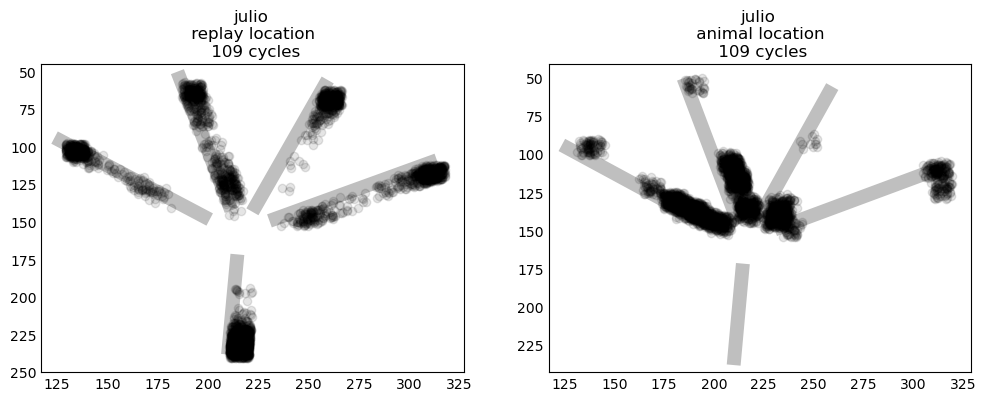

In [16]:
animal_ind = 0
animals = ["julio"] #["molly","eliot","julio","lewis","klein"]
parameter_name = "params_both_max_all_maze_2_state"

output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
for animal in animals:
    
    list_of_days = list_of_days_animals[animal]

    save_name = return_save_name(animal, parameter_name, list_of_days[0], list_of_days[-1], proportion = 0.1)
    file_path = output_folder + save_name + '.pkl'
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    replay_locations = loaded_data["replay_locations"]
    animal_locations = loaded_data["animal_locations"]

    plot_density(animal, replay_locations, animal_locations, use_all = True)

    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/"
    plt.savefig(file_path + f"location_by_event{animal}.pdf",bbox_inches='tight')
    plt.savefig(file_path + f"location_by_event{animal}.png",bbox_inches='tight')


### Quantify for all outer arms

In [20]:
animal_ind = 0
animals = ["molly","eliot","julio","lewis","klein"]

replay_arm_proportions_animals = {}
parameter_name = "params_both_max_all_maze_2_state"
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
for animal in animals:
    
    list_of_days = list_of_days_animals[animal]

    save_name = return_save_name(animal, parameter_name, list_of_days[0], list_of_days[-1], proportion = 0.1)
    file_path = output_folder + save_name + '.pkl'
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    replay_arm_proportions = loaded_data["replay_arm_proportions"]
    replay_arm_identities = np.array(loaded_data["replay_arm_identities"])

    prop_mean_per_cycle = []
    for r in replay_arm_proportions: # get rid of some occasional 1-2 datapoints are off the arm
        r = r[r > 0]
        r = r[r < 1]
        prop_mean_per_cycle.append(np.mean(r))

    prop_mean_per_cycle = np.array(prop_mean_per_cycle)
    assert len(prop_mean_per_cycle) == len(replay_arm_identities)

    replay_arm_proportions_animals[animal] = {}

    for a in [0,1,2,3,4]:
        prop = prop_mean_per_cycle[replay_arm_identities == a]
        if a == 0:
            replay_arm_proportions_animals[animal][a] = 1 - prop
        else:
            replay_arm_proportions_animals[animal][a] = prop

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/molly_params_both_max_all_maze_2_state_20220415_20220420_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/eliot_params_both_max_all_maze_2_state_20221018_20221026_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/julio_params_both_max_all_maze_2_state_20230731_20230811_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_params_both_max_all_maze_2_state_20240105_20240110_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/klein_params_both_max_all_maze_2_state_20231101_20231108_p0.1_remote_locations.pkl':


### Make bar plot

In [35]:
import seaborn as sns

In [21]:
hist_pct = {}
hist_count = {}

bin_width = 0.2
bins = np.arange(0,1+bin_width,bin_width)


for animal in ["molly","eliot","julio","lewis","klein"]:
    
    hist_count[animal], hist_pct[animal] = {}, {}
    for arm in replay_arm_proportions_animals[animal]:
        data = replay_arm_proportions_animals[animal][arm]
        hist, bin_edges = np.histogram(data, bins, weights = np.ones_like(data)/len(data))
        hist_pct[animal][arm] = hist

        hist, bin_edges = np.histogram(data, bins)
        hist_count[animal][arm] = hist
    


In [22]:
def return_sd_prop(p,n):
    sd = np.sqrt(p*(1-p)/n)
    sd[n == 0] = 0
    return sd

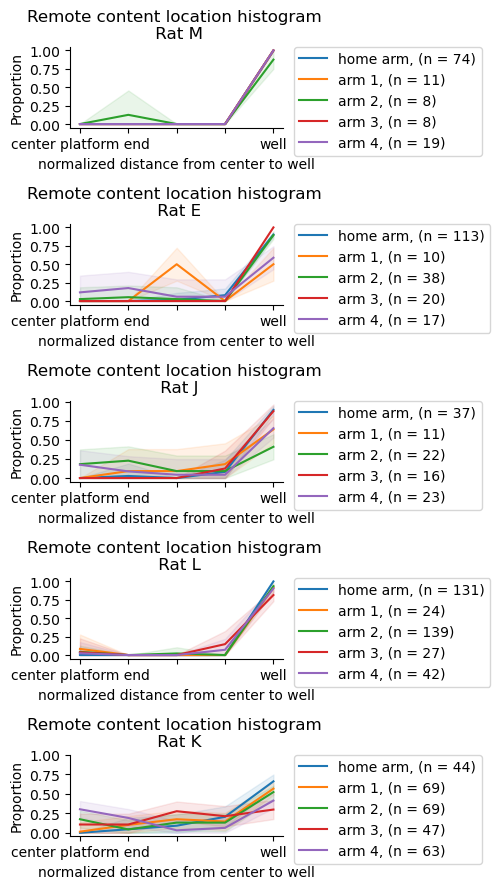

In [39]:
animal_ind = 0

fig, axes = plt.subplots(5,1,figsize = (5.2,9))
animals = ["molly","eliot","julio","lewis","klein"]

output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
for animal in animals:
    
    for arm in [0,1,2,3,4]:
        n = hist_count[animal][arm]
        p = hist_pct[animal][arm]
        sd = return_sd_prop(p,n)

        if arm == 0:
            label = f'home arm, (n = {np.sum(n)})'
        else:
            label = f'arm {arm}, (n = {np.sum(n)})'
        axes[animal_ind].plot(bins[:-1] + 0.1, p, color = 'C'+str(arm),label = label)
        axes[animal_ind].fill_between(bins[:-1] + 0.1, np.clip(p-sd,0,a_max=None), p + sd, alpha = 0.1, color = 'C'+str(arm))
        
    axes[animal_ind].set_title('Remote content location histogram \n Rat ' + str(animal[0]).upper())
    axes[animal_ind].set_ylabel("Proportion")
    axes[animal_ind].set_xlabel("normalized distance from center to well")
    axes[animal_ind].set_xticks(bins[:-1] + 0.1)
    axes[animal_ind].set_xticklabels(['center platform end',"","","",'well'])
    axes[animal_ind].set_yticks(np.linspace(0,1,5))
    axes[animal_ind].spines[['right', 'top']].set_visible(False)
    #axes.set_yticks(np.linspace(0,1,5))

    axes[animal_ind].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    animal_ind += 1
    
plt.tight_layout()
file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/"
plt.savefig(file_path + "arm_proportion.pdf",bbox_inches='tight')
plt.savefig(file_path + "arm_proportion.png",bbox_inches='tight')

### Linear regression for individual rats

In [24]:
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    model, result = GLM_by_animal(hist_pct[animal])
    coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(result)
    coef_est = np.exp(coef_est)
    coef_pd = np.exp(coef_pd)
    CI = np.exp(CI)
    

    a = coef_pd["bin5"]
    b = pvalues["bin5"]
    c = CI.loc["bin5"][0]
    d = CI.loc["bin5"][1]
    print(f"{animal}: estimate of end of arm {np.round(a,2)}, {np.round(b,4)}, with CI {np.round(c,2)}, {np.round(d,2)}")
    #print(result.summary())

molly: estimate of end of arm 357.93, 0.0, with CI 108.41, 1181.79
eliot: estimate of end of arm 41.7, 0.0078, with CI 3.0, 579.78
julio: estimate of end of arm 13.59, 0.0321, with CI 1.28, 144.48
klein: estimate of end of arm 3.02, 0.0922, with CI 0.82, 11.1
lewis: estimate of end of arm 101.06, 0.0001, with CI 14.03, 728.07


In [26]:
np.exp(-1.7)

0.18268352405273466

### Stop here

### Mixed linear Effect

In [27]:
import numpy.matlib as ml
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

In [28]:
bin_width = 0.2 #DO NOT CHANGE, AS IT IS SET IN THE LAST CELL where data calculations happen
bins = np.arange(0,1+bin_width,bin_width) #DO NOT CHANGE, AS IT IS SET IN THE LAST CELL
arms = [0,1,2,3,4]

animal_ind = 0
animals = ["julio","lewis","eliot","molly","klein"]

GLM_x = []
GLM_y = []
for animal in animals:
    GLM_x_animal = []
    GLM_y_animal = []
    for arm in arms:
        
        prop_animal_arm = hist_pct[animal][arm]
        N = len(prop_animal_arm)

        # add arm catogory
        arm_catogory = np.array([_ == arm for _ in arms]).reshape((1,-1))
        X_arm_catogory = ml.repmat(arm_catogory, N, 1)
        X_animal_arm = np.hstack((
            bins[:-1].reshape((-1,1)),
            X_arm_catogory))

        Y_animal_arm = prop_animal_arm.reshape((-1,1))

        GLM_x_animal.append(X_animal_arm)
        GLM_y_animal.append(Y_animal_arm)

    # concat across arms
    GLM_x_animal = np.vstack(GLM_x_animal)
    GLM_y_animal = np.vstack(GLM_y_animal)
    
    # add animal catogory
    animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
    X_animal_category = ml.repmat(animal_category, np.shape(GLM_x_animal)[0], 1)
    X_animal = np.hstack((X_animal_category, GLM_x_animal)).astype("float")
    Y_animal = GLM_y_animal.astype("float")

    GLM_x.append(X_animal)
    GLM_y.append(Y_animal)

    
GLM_x = np.vstack(GLM_x)
GLM_y = np.vstack(GLM_y)

In [33]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["arm proportion"] = GLM_x[:,len(animals)]
feature_dict["home arm"] = GLM_x[:,(len(animals)+1)]
feature_dict["arm 1"] = GLM_x[:,(len(animals)+2)]
feature_dict["arm 2"] = GLM_x[:,(len(animals)+3)]
feature_dict["arm 3"] = GLM_x[:,(len(animals)+4)]
feature_dict["arm 4"] = GLM_x[:,(len(animals)+5)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_y

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(np.log(y + 0.0001),X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                     10.51
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           9.69e-12
Time:                        08:18:11   Log-Likelihood:                -305.40
No. Observations:                 125   AIC:                             630.8
Df Residuals:                     115   BIC:                             659.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -5.0

In [34]:
p = ols_result1.pvalues["arm proportion"]
print(f"The pvalue of arm proportion is predicting the probability of remote event is {p}")

The pvalue of arm proportion is predicting the probability of remote event is 1.4083631644620214e-09


In [37]:
mean = ols_result1.params.loc["arm proportion"]
CI = ols_result1.conf_int(alpha=0.05)
prop_CI = CI.loc["arm proportion"]

print(f"The effect of arm proportion is {mean}, with 95% bound: {prop_CI[0],prop_CI[1]}")

The effect of arm proportion is 6.048186989212546, with 95% bound: (4.229378288112231, 7.866995690312861)
